# **Lyotropic Gels**

## **Set up()**

In [40]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as mticker
from scipy.special import gamma, jv

## **Data**

In [2]:
green = pd.read_csv(r"E:\Zalygin geles\SAXS gels\green.dat", sep=str('  '), 
                      skiprows=5, names=['q', 'I', 'err'], encoding='latin1')
red = pd.read_csv(r"E:\Zalygin geles\SAXS gels\red.dat", sep=str('  '), 
                      skiprows=5, names=['q', 'I', 'err'], encoding='latin1')

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_5056\2727612186.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  green = pd.read_csv(r"E:\Zalygin geles\SAXS gels\green.dat", sep=str('  '),
C:\Users\LabPCA\AppData\Local\Temp\ipykernel_5056\2727612186.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  red = pd.read_csv(r"E:\Zalygin geles\SAXS gels\red.dat", sep=str('  '),


# **Functions**

In [24]:
def hex_Sq(q, g, delta, nu, c, Delta):
    """
    Структурный фактор для гексагональной решетки по модели Glatter (eq 28-35).
    """
    # ---- 1. Позиции пиков для HEX ----
    hk = [(1,0), (1,1), (2,0), (2,1), (3,0), (2,2), (3,1), (4,0), (3,2), (4,1)]
    q_hk = np.array([4*np.pi/(np.sqrt(3)*g) * np.sqrt(h**2 + h*k + k**2) for h,k in hk])
    
    # ---- 2. Мультипликаторы ----
    m = np.array([6 if (h==0 or k==0 or h==k) else 12 for h,k in hk])
    
    # ---- 3. Фактор симметрии (для HEX все = 1) ----
    f = np.ones_like(m)
    
    # ---- 4. Peak shape function L_hk(q) из eq 29 ----
    gamma_nu = np.pi**0.5 * gamma(nu + 0.5) / gamma(nu/2)
    
    # ---- 5. Суммируем все пики в Z0 ----
    Z0 = np.zeros_like(q, dtype=complex)  # complex из-за gamma с 1j
    
    for i, q0 in enumerate(q_hk):
        x = 2 * (q - q0) / (np.pi * delta)
        numerator = gamma(nu/2 + 1j * gamma_nu * x)
        denominator = gamma(nu/2)
        L = (2/(np.pi*delta)) * np.abs(numerator / denominator)**2
        
        # prefactor = c / (sqrt(3) * g^2 * q)  # для d=2
        prefactor = c / (np.sqrt(3) * g**2 * q)
        
        Z0 += prefactor * m[i] * f[i]**2 * L
    
    # ---- 6. Дебая-Валлер (eq 33) ----
    G = np.exp(-Delta * q**2)
    
    # ---- 7. Структурный фактор (eq 34) ----
    S = 1 + (Z0 - 1) * G
    
    return np.real(S)  # убираем мнимую часть (должна быть ~0)

In [36]:
def cylinder_Pc(q, R):
    """
    Cross-section form factor для однородного цилиндра радиуса R.
    P_c(q) = [2*J1(qR)/(qR)]^2
    """
    x = q * R
    return (2 * jv(1, x) / x)**2

In [96]:
def cylinder_Pc_core_shell(q, R_core, R_total, rho_core, rho_shell):
    """
    Cross-section form factor для цилиндра с ядром и оболочкой.
    """
    def F(q, R):
        return 2 * jv(1, q * R) / (q * R)
    
    F_core = F(q, R_core)
    F_total = F(q, R_total)
    
    F = rho_core * F_core + rho_shell * (F_total - F_core)
    
    return np.real(F * np.conj(F))

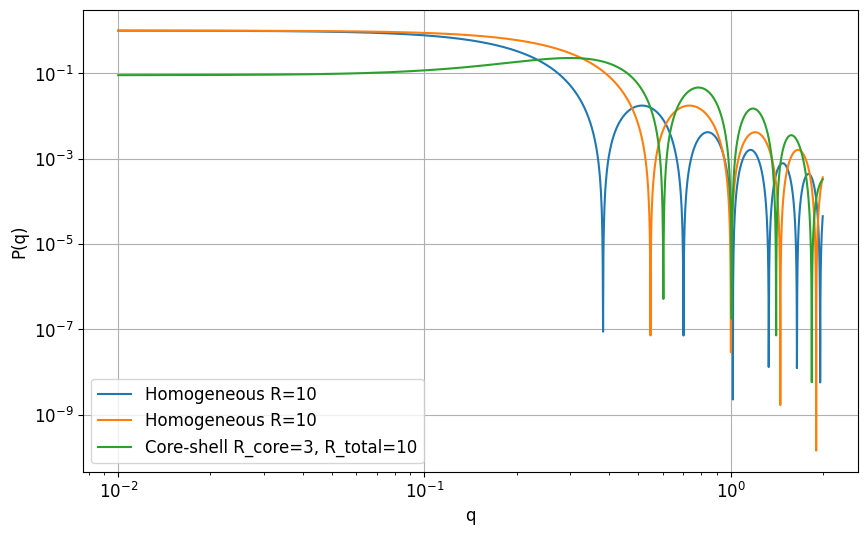

In [101]:
q = np.linspace(0.01, 2.0, 2000)

# Однородный цилиндр R=10
P_hom = cylinder_Pc(q, 10.0)
plt.loglog(q, P_hom, label='Homogeneous R=10')

# Core-shell: R_core=3, R_total=10
P_cs = cylinder_Pc_core_shell(q, 7.0, 10.0, -0.3, 1.0)

P_hom = cylinder_Pc(q, 7.0)
plt.loglog(q, P_hom, label='Homogeneous R=10')
plt.loglog(q, P_cs, label='Core-shell R_core=3, R_total=10')

plt.xlabel('q')
plt.ylabel('P(q)')
plt.legend()
plt.grid()

## Analysis

In [25]:
hex_Sq

<function __main__.hex_Sq(q, g, delta, nu, c, Delta)>

In [38]:
cylinder_Pc_core_shell

<function __main__.cylinder_Pc_core_shell(q, R_core, R_total, rho_core, rho_shell)>

In [26]:
4*pi/np.sqrt(3)/0.665

np.float64(10.910071363814843)

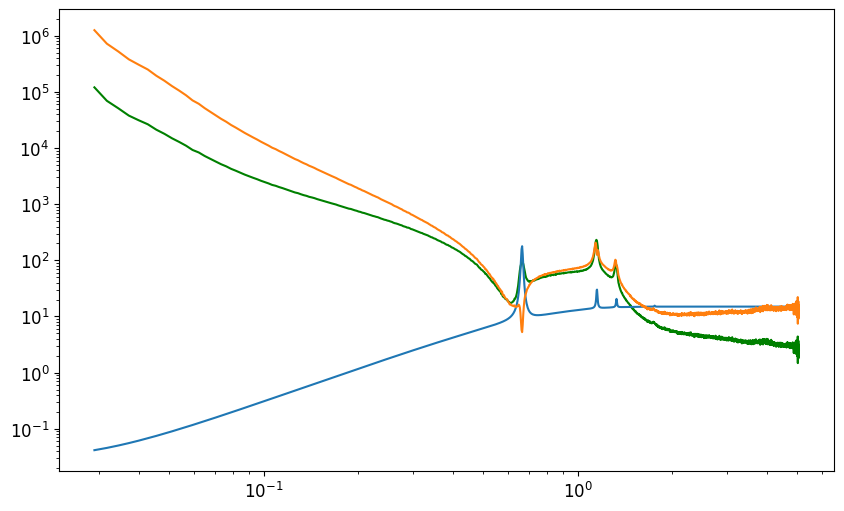

In [147]:
q, I = green['q'], green['I'] / 1e3

plt.loglog(q, I, color='green')

Sq = hex_Sq(q, 10.9, 0.01, 0.033, 10, 2)
plt.plot(q, Sq * 15)

Pq = cylinder_Pc_core_shell(q, 2, 6, 100, 0.1) * 1e1
# plt.plot(q, Pq / q )

Pq = cylinder_Pc_core_shell(q, 6.5, 18, 100, 0.1) * 1e1
plt.plot(q, I / Sq * q  )

# plt.axvline(x=0.65)
# plt.axvline(x=1.8)

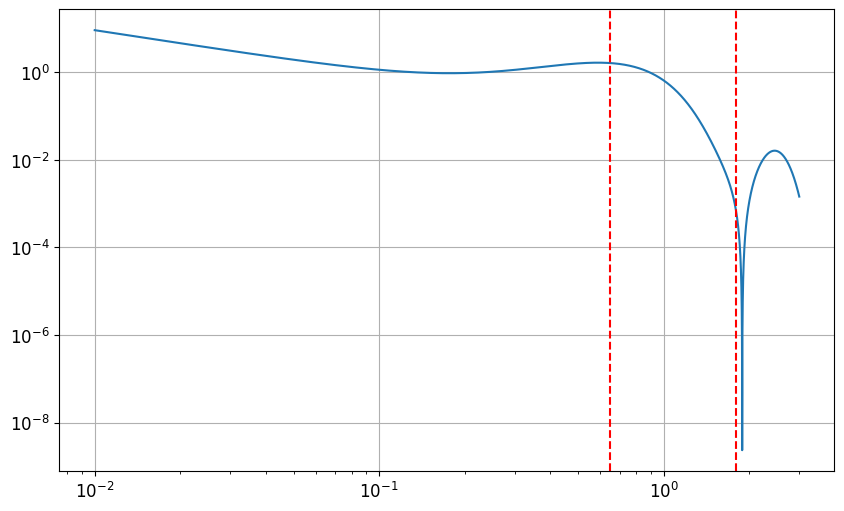

In [133]:
q = np.linspace(0.01, 3.0, 5000)

# Твой случай
R_core = 2.1
R_total = 5.9
P = cylinder_Pc_core_shell(q, R_core, R_total, -0.3, 1.0)

plt.loglog(q, P / q)  # с фактором Лоренца
plt.axvline(0.65, color='red', linestyle='--', label='min 1')
plt.axvline(1.8, color='red', linestyle='--', label='min 2')
# plt.xlim(0, 2.5)
plt.yscale('log')
plt.grid()
plt.show()

## Peak posit

In [43]:
x = np.array([0.666, 1.149, 1.326, 1.751])
print(x / 0.666)
print(x ** 2 / 0.666 ** 2)
print('Hexagonal')

[1.         1.72522523 1.99099099 2.62912913]
[1.         2.97640208 3.96404513 6.91231998]
Hexagonal


In [46]:
x = np.array([0.5547, 0.9101, 1.056, 1.103, 1.286, 1.391])
print(x / 0.5547)
print((x / 0.5547)**2 * 3)
print('FCC')

[1.         1.64070669 1.90373175 1.98846223 2.31837029 2.5076618 ]
[ 3.          8.07575531 10.87258369 11.86194614 16.12452241 18.8651031 ]
FCC
